Transformer_Project.ipynb

01. 라이브러리 import
02. Device 설정
03. 데이터 불러오기
04. 데이터 전처리
05. SentencePiece 학습
06. Tensor 생성

07. Positional Encoding
08. Mask
09. MultiHeadAttention
10. FeedForward
11. EncoderLayer
12. DecoderLayer
13. Encoder
14. Decoder
15. Transformer

16. Loss
17. Scheduler
18. Train Step
19. Train
20. Translate
21. Attention Visualization

In [1]:
# =====================================================
# 1. Library Import
# =====================================================

import os
import re
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import sentencepiece as spm

from tqdm.notebook import tqdm

In [2]:
# =====================================================
# 2. Device
# =====================================================

# Apple Silicon
if torch.backends.mps.is_available():
    device = torch.device("mps")

# NVIDIA GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")

# CPU
else:
    device = torch.device("cpu")

print("="*50)
print("PyTorch :", torch.__version__)
print("Device  :", device)
print("="*50)

PyTorch : 2.7.1+cu118
Device  : cuda


In [3]:
# =====================================================
# 3. Load Dataset
# =====================================================

data_dir = "./data"

ko_path = os.path.join(data_dir, "korean-english-park.train.ko")
en_path = os.path.join(data_dir, "korean-english-park.train.en")


def load_data(path):
    with open(path, encoding="utf-8") as f:
        return f.read().splitlines()


raw_ko = load_data(ko_path)
raw_en = load_data(en_path)

print("한국어 문장 수 :", len(raw_ko))
print("영어 문장 수 :", len(raw_en))

print("\n예시")

print(raw_ko[0])
print(raw_en[0])

한국어 문장 수 : 94123
영어 문장 수 : 94123

예시
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
Much of personal computing is about "can you top this?"


In [4]:
# =====================================================
# 4. Sentence Preprocessing
# =====================================================

def preprocess_sentence(sentence):
    """
    영어/한글 문장 전처리

    1. 소문자 변환
    2. 앞뒤 공백 제거
    3. 문장부호 분리
    4. 여러 공백 제거
    5. 특수문자 제거
    """

    sentence = sentence.lower().strip()

    # punctuation 앞뒤 띄우기
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 여러 공백 제거
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 한글 / 영어 / 문장부호만 남기기
    sentence = re.sub(
        r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z?.!,]+",
        " ",
        sentence,
    )

    sentence = sentence.strip()

    return sentence


print(preprocess_sentence(raw_ko[0]))
print(preprocess_sentence(raw_en[0]))

개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
much of personal computing is about can you top this ?


In [5]:
# =====================================================
# Cell 5. Data Cleaning
# =====================================================

# 중복 제거
cleaned_corpus = list(set(zip(raw_ko, raw_en)))

print("중복 제거 전 :", len(raw_ko))
print("중복 제거 후 :", len(cleaned_corpus))

kor_corpus = []
eng_corpus = []

for ko, en in cleaned_corpus:

    # 전처리
    ko = preprocess_sentence(ko)
    en = preprocess_sentence(en)

    # 빈 문장 제거
    if len(ko) == 0 or len(en) == 0:
        continue

    kor_corpus.append(ko)
    eng_corpus.append(en)

print("\n최종 데이터 개수 :", len(kor_corpus))

print("\n예시")
print(kor_corpus[0])
print(eng_corpus[0])

중복 제거 전 : 94123
중복 제거 후 : 78968

최종 데이터 개수 : 78956

예시
레바논 북부 지역의 전투로 민간인 명과 무장대원 명이 숨졌다 .
at least civilians and about militants have also been killed in the northern lebanon fighting , but civilian casualties in the camp in the last four days were unknown .


In [6]:
# =====================================================
# Cell 6. SentencePiece Tokenizer
# =====================================================

SRC_VOCAB_SIZE = 20000
TGT_VOCAB_SIZE = 20000


def generate_tokenizer(corpus,
                       vocab_size,
                       lang):

    txt_file = f"{lang}_corpus.txt"

    with open(txt_file, "w", encoding="utf-8") as f:
        for sentence in corpus:
            f.write(sentence + "\n")

    model_prefix = f"{lang}_spm"

    spm.SentencePieceTrainer.Train(
        f"--input={txt_file} "
        f"--model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} "
        f"--character_coverage=1.0 "
        f"--model_type=unigram "
        f"--pad_id=0 "
        f"--bos_id=1 "
        f"--eos_id=2 "
        f"--unk_id=3"
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model_prefix}.model")

    return tokenizer


print("한국어 토크나이저 생성")
ko_tokenizer = generate_tokenizer(
    kor_corpus,
    SRC_VOCAB_SIZE,
    "ko"
)

print("영어 토크나이저 생성")
en_tokenizer = generate_tokenizer(
    eng_corpus,
    TGT_VOCAB_SIZE,
    "en"
)

# Decoder 입력용
en_tokenizer.set_encode_extra_options("bos:eos")

한국어 토크나이저 생성


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --character_coverage=1.0 --model_type=unigram --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limi

영어 토크나이저 생성


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=en_corpus.txt --model_prefix=en_spm --vocab_size=20000 --character_coverage=1.0 --model_type=unigram --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: en_corpus.txt
  input_format: 
  model_prefix: en_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limi

True

In [7]:
# =====================================================
# Cell 7. Tokenization
# =====================================================

MAX_LENGTH = 50

src_corpus = []
tgt_corpus = []

for ko, en in tqdm(zip(kor_corpus, eng_corpus),
                   total=len(kor_corpus)):

    src = ko_tokenizer.encode_as_ids(ko)
    tgt = en_tokenizer.encode_as_ids(en)

    # 너무 긴 문장은 제거
    if len(src) > MAX_LENGTH:
        continue

    if len(tgt) > MAX_LENGTH:
        continue

    src_corpus.append(torch.tensor(src))
    tgt_corpus.append(torch.tensor(tgt))

print("사용할 문장 수 :", len(src_corpus))

  0%|          | 0/78956 [00:00<?, ?it/s]

사용할 문장 수 : 72078


In [8]:
# =====================================================
# Cell 8. Padding
# =====================================================

enc_train = torch.nn.utils.rnn.pad_sequence(
    src_corpus,
    batch_first=True,
    padding_value=0
)

dec_train = torch.nn.utils.rnn.pad_sequence(
    tgt_corpus,
    batch_first=True,
    padding_value=0
)

print("Encoder :", enc_train.shape)
print("Decoder :", dec_train.shape)

Encoder : torch.Size([72078, 50])
Decoder : torch.Size([72078, 50])


In [9]:
# =====================================================
# Cell 9. Positional Encoding
# =====================================================

class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding
    """

    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()

        # (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        # 짝수 index → sin
        pe[:, 0::2] = torch.sin(position * div_term)

        # 홀수 index → cos
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        # 학습되지 않는 Tensor로 등록
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x : (batch, seq_len, d_model)
        """

        seq_len = x.size(1)

        x = x + self.pe[:, :seq_len]

        return x

In [10]:
# =====================================================
# Cell 10. Transformer Mask
# =====================================================

def create_padding_mask(seq):
    """
    Padding Token(0)을 Mask 처리
    """

    mask = (seq == 0).unsqueeze(1).unsqueeze(2)

    return mask


def create_look_ahead_mask(size):
    """
    미래 단어를 보지 못하도록 하는 Mask
    """

    mask = torch.triu(
        torch.ones(size, size),
        diagonal=1
    ).bool()

    return mask


def generate_masks(src, tgt):
    """
    Encoder / Decoder Mask 생성
    """

    # Encoder Padding Mask
    enc_padding_mask = create_padding_mask(src)

    # Decoder에서 Encoder를 볼 때 사용하는 Mask
    dec_enc_padding_mask = create_padding_mask(src)

    # Decoder Padding Mask
    dec_padding_mask = create_padding_mask(tgt)

    # Look Ahead Mask
    look_ahead_mask = create_look_ahead_mask(
        tgt.size(1)
    ).to(tgt.device)

    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(1)

    dec_mask = dec_padding_mask | look_ahead_mask

    return (
        enc_padding_mask,
        dec_enc_padding_mask,
        dec_mask
    )

In [11]:
# =====================================================
# Cell 11. Scaled Dot Product Attention
# =====================================================

class ScaledDotProductAttention(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(
        self,
        Q,
        K,
        V,
        mask=None
    ):

        d_k = Q.size(-1)

        # Attention Score
        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        scores = scores / math.sqrt(d_k)

        # Mask 적용
        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)

        # Softmax
        attention = F.softmax(
            scores,
            dim=-1
        )

        output = torch.matmul(
            attention,
            V
        )

        return output, attention

In [12]:
# =====================================================
# Cell 12. Multi Head Attention
# =====================================================

class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads
    ):

        super().__init__()

        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.Wq = nn.Linear(
            d_model,
            d_model
        )

        self.Wk = nn.Linear(
            d_model,
            d_model
        )

        self.Wv = nn.Linear(
            d_model,
            d_model
        )

        self.fc = nn.Linear(
            d_model,
            d_model
        )

        self.attention = ScaledDotProductAttention()

    def split_heads(self, x):

        batch = x.size(0)

        x = x.view(
            batch,
            -1,
            self.num_heads,
            self.depth
        )

        return x.transpose(1, 2)

    def forward(
        self,
        Q,
        K,
        V,
        mask=None
    ):

        batch = Q.size(0)

        Q = self.Wq(Q)
        K = self.Wk(K)
        V = self.Wv(V)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        output, attention = self.attention(
            Q,
            K,
            V,
            mask
        )

        output = output.transpose(
            1,
            2
        ).contiguous()

        output = output.view(
            batch,
            -1,
            self.d_model
        )

        output = self.fc(output)

        return output, attention

In [13]:
# =====================================================
# Cell 13. Position-wise Feed Forward Network
# =====================================================

class PositionwiseFeedForward(nn.Module):
    """
    Position-wise Feed Forward Network

    Linear(d_model → d_ff)
        ↓
      ReLU
        ↓
    Linear(d_ff → d_model)
    """

    def __init__(self,
                 d_model,
                 d_ff,
                 dropout=0.1):

        super().__init__()

        self.linear1 = nn.Linear(d_model, d_ff)

        self.linear2 = nn.Linear(d_ff, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        x = self.linear1(x)

        x = F.relu(x)

        x = self.dropout(x)

        x = self.linear2(x)

        return x

In [14]:
# =====================================================
# Cell 14. Encoder Layer
# =====================================================

class EncoderLayer(nn.Module):

    def __init__(self,
                 d_model,
                 num_heads,
                 d_ff,
                 dropout=0.1):

        super().__init__()

        # Multi Head Attention
        self.self_attention = MultiHeadAttention(
            d_model,
            num_heads
        )

        # Feed Forward
        self.ffn = PositionwiseFeedForward(
            d_model,
            d_ff,
            dropout
        )

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)

        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout1 = nn.Dropout(dropout)

        self.dropout2 = nn.Dropout(dropout)

    def forward(self,
                x,
                mask):

        # -----------------------------
        # Self Attention
        # -----------------------------
        attn_output, attn = self.self_attention(
            x,
            x,
            x,
            mask
        )

        attn_output = self.dropout1(attn_output)

        # Residual Connection
        x = self.norm1(
            x + attn_output
        )

        # -----------------------------
        # Feed Forward
        # -----------------------------
        ffn_output = self.ffn(x)

        ffn_output = self.dropout2(ffn_output)

        # Residual Connection
        out = self.norm2(
            x + ffn_output
        )

        return out, attn

In [15]:
# test
encoder_layer = EncoderLayer(
    d_model=512,
    num_heads=8,
    d_ff=2048
)

x = torch.randn(2, 20, 512)

mask = create_padding_mask(
    torch.ones(2,20)
)

out, attn = encoder_layer(
    x,
    mask
)

print(out.shape)
print(attn.shape)

torch.Size([2, 20, 512])
torch.Size([2, 8, 20, 20])


In [16]:
# =====================================================
# Cell 15. Decoder Layer
# =====================================================

class DecoderLayer(nn.Module):

    def __init__(self,
                 d_model,
                 num_heads,
                 d_ff,
                 dropout=0.1):

        super().__init__()

        # Masked Self Attention
        self.self_attention = MultiHeadAttention(
            d_model,
            num_heads
        )

        # Encoder-Decoder Attention
        self.enc_dec_attention = MultiHeadAttention(
            d_model,
            num_heads
        )

        # Feed Forward
        self.ffn = PositionwiseFeedForward(
            d_model,
            d_ff,
            dropout
        )

        # LayerNorm
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self,
                x,
                enc_output,
                look_ahead_mask,
                padding_mask):

        # -----------------------------------
        # 1. Masked Self Attention
        # -----------------------------------

        attn1, dec_self_attn = self.self_attention(
            x,
            x,
            x,
            look_ahead_mask
        )

        attn1 = self.dropout1(attn1)

        x = self.norm1(
            x + attn1
        )

        # -----------------------------------
        # 2. Encoder Decoder Attention
        # -----------------------------------

        attn2, dec_enc_attn = self.enc_dec_attention(
            x,
            enc_output,
            enc_output,
            padding_mask
        )

        attn2 = self.dropout2(attn2)

        x = self.norm2(
            x + attn2
        )

        # -----------------------------------
        # 3. Feed Forward
        # -----------------------------------

        ffn = self.ffn(x)

        ffn = self.dropout3(ffn)

        out = self.norm3(
            x + ffn
        )

        return out, dec_self_attn, dec_enc_attn

In [17]:
# =====================================================
# Cell 16. Encoder
# =====================================================

class Encoder(nn.Module):

    def __init__(self,
                 vocab_size,
                 d_model,
                 num_layers,
                 num_heads,
                 d_ff,
                 dropout=0.1,
                 max_len=5000):

        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=0
        )

        self.position = PositionalEncoding(
            d_model,
            max_len
        )

        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList(
            [
                EncoderLayer(
                    d_model,
                    num_heads,
                    d_ff,
                    dropout
                )
                for _ in range(num_layers)
            ]
        )

    def forward(
        self,
        x,
        mask
    ):

        attn_list = []

        x = self.embedding(x)

        x = x * math.sqrt(self.d_model)

        x = self.position(x)

        x = self.dropout(x)

        for layer in self.layers:

            x, attn = layer(
                x,
                mask
            )

            attn_list.append(attn)

        return x, attn_list

In [18]:
# =====================================================
# Cell 17. Decoder
# =====================================================

class Decoder(nn.Module):

    def __init__(self,
                 vocab_size,
                 d_model,
                 num_layers,
                 num_heads,
                 d_ff,
                 dropout=0.1,
                 max_len=5000):

        super().__init__()

        self.d_model = d_model

        # Target Embedding
        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=0
        )

        # Positional Encoding
        self.position = PositionalEncoding(
            d_model,
            max_len
        )

        self.dropout = nn.Dropout(dropout)


        # Decoder Layer 여러 개 쌓기
        self.layers = nn.ModuleList(
            [
                DecoderLayer(
                    d_model,
                    num_heads,
                    d_ff,
                    dropout
                )
                for _ in range(num_layers)
            ]
        )


    def forward(self,
                x,
                enc_output,
                look_ahead_mask,
                padding_mask):


        self_attentions = []
        enc_dec_attentions = []


        # Embedding
        x = self.embedding(x)


        # Scaling
        x = x * math.sqrt(self.d_model)


        # Position 정보 추가
        x = self.position(x)


        x = self.dropout(x)


        # Decoder Layer 반복
        for layer in self.layers:

            x, self_attn, enc_dec_attn = layer(
                x,
                enc_output,
                look_ahead_mask,
                padding_mask
            )


            self_attentions.append(self_attn)

            enc_dec_attentions.append(
                enc_dec_attn
            )


        return (
            x,
            self_attentions,
            enc_dec_attentions
        )

In [19]:
decoder = Decoder(
    vocab_size=20000,
    d_model=512,
    num_layers=2,
    num_heads=8,
    d_ff=2048
)


x = torch.randint(
    0,
    20000,
    (2,10)
)


enc = torch.randn(
    2,
    20,
    512
)


look_mask = torch.zeros(
    1,1,10,10
).bool()


pad_mask = torch.zeros(
    2,1,1,20
).bool()



output, self_attn, enc_attn = decoder(
    x,
    enc,
    look_mask,
    pad_mask
)


print(output.shape)

torch.Size([2, 10, 512])


In [20]:
# =====================================================
# Cell 18. Transformer
# =====================================================

class Transformer(nn.Module):

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=512,
        num_layers=2,
        num_heads=8,
        d_ff=2048,
        dropout=0.1,
        max_len=5000
    ):

        super().__init__()


        # Encoder
        self.encoder = Encoder(
            vocab_size=src_vocab_size,
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
            max_len=max_len
        )


        # Decoder
        self.decoder = Decoder(
            vocab_size=tgt_vocab_size,
            d_model=d_model,
            num_layers=num_layers,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout,
            max_len=max_len
        )


        # 최종 단어 예측 Linear
        self.output_layer = nn.Linear(
            d_model,
            tgt_vocab_size
        )


    def forward(
        self,
        src,
        tgt,
        enc_padding_mask,
        dec_enc_padding_mask,
        dec_padding_mask
    ):


        # ============================
        # Encoder
        # ============================

        enc_output, enc_attns = self.encoder(
            src,
            enc_padding_mask
        )


        # ============================
        # Decoder
        # ============================

        dec_output, dec_attns, dec_enc_attns = self.decoder(
            tgt,
            enc_output,
            dec_padding_mask,
            dec_enc_padding_mask
        )


        # ============================
        # Vocabulary Prediction
        # ============================

        predictions = self.output_layer(
            dec_output
        )


        return (
            predictions,
            enc_attns,
            dec_attns,
            dec_enc_attns
        )

In [21]:
# =====================================================
# Test Transformer
# =====================================================

model = Transformer(
    src_vocab_size=20000,
    tgt_vocab_size=20000,
    d_model=512,
    num_layers=2,
    num_heads=8,
    d_ff=2048
).to(device)



src = torch.randint(
    0,
    20000,
    (2,20)
).to(device)



tgt = torch.randint(
    0,
    20000,
    (2,15)
).to(device)



enc_mask, dec_enc_mask, dec_mask = generate_masks(
    src,
    tgt
)



output = model(
    src,
    tgt,
    enc_mask,
    dec_enc_mask,
    dec_mask
)



print(output[0].shape)

torch.Size([2, 15, 20000])


In [22]:
# =====================================================
# Cell 19. Loss Function
# =====================================================

# Cross Entropy Loss
# reduction="none"으로 설정해서
# 각 token별 loss를 계산

loss_object = nn.CrossEntropyLoss(
    reduction="none"
)


def loss_function(real, pred):
    """
    real : 정답 token
           (batch, seq_len)

    pred : 모델 출력
           (batch, seq_len, vocab_size)
    """

    # Padding token(0)이 아닌 위치만 학습
    mask = (real != 0).float()


    # Cross Entropy 계산을 위해 reshape

    loss = loss_object(
        pred.reshape(-1, pred.size(-1)),
        real.reshape(-1)
    )


    # 원래 문장 형태로 변경

    loss = loss.reshape(
        real.size()
    )


    # Padding 위치 제거

    loss = loss * mask


    # 실제 token 개수 기준 평균

    return loss.sum() / mask.sum()

In [23]:
# =====================================================
# Loss Test
# =====================================================

batch = 2
seq_len = 5
vocab_size = 10000


pred = torch.randn(
    batch,
    seq_len,
    vocab_size
)


real = torch.randint(
    1,
    vocab_size,
    (batch, seq_len)
)


loss = loss_function(
    real,
    pred
)


print(loss)

tensor(9.8812)


In [24]:
# =====================================================
# Cell 20. Learning Rate Scheduler
# =====================================================

class LearningRateScheduler(
    torch.optim.lr_scheduler._LRScheduler
):
    """
    Transformer Warmup Learning Rate Scheduler

    논문:
    Attention Is All You Need
    """

    def __init__(
        self,
        optimizer,
        d_model,
        warmup_steps=4000,
        last_epoch=-1
    ):

        self.d_model = d_model

        self.warmup_steps = warmup_steps

        super().__init__(
            optimizer,
            last_epoch
        )


    def get_lr(self):

        step = max(
            1,
            self.last_epoch
        )


        # warmup 후 감소하는 learning rate

        arg1 = step ** (-0.5)


        arg2 = (
            step *
            (self.warmup_steps ** (-1.5))
        )


        lr = (
            self.d_model ** (-0.5)
        ) * min(
            arg1,
            arg2
        )


        return [
            lr
            for _ in self.base_lrs
        ]

In [25]:
# =====================================================
# Optimizer
# =====================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0,
    betas=(0.9, 0.98),
    eps=1e-9
)


scheduler = LearningRateScheduler(
    optimizer,
    d_model=512,
    warmup_steps=4000
)

In [26]:
# =====================================================
# Scheduler Test
# =====================================================

for step in range(1,10):

    optimizer.step()

    scheduler.step()

    lr = optimizer.param_groups[0]["lr"]

    print(
        step,
        lr
    )

1 1.746928107421711e-07
2 3.493856214843422e-07
3 5.240784322265133e-07
4 6.987712429686844e-07
5 8.734640537108554e-07
6 1.0481568644530267e-06
7 1.2228496751951977e-06
8 1.3975424859373688e-06
9 1.57223529667954e-06


In [27]:
# =====================================================
# Cell 21. Train Step
# =====================================================


def train_step(
    src,
    tgt,
    model,
    optimizer,
    scheduler
):

    model.train()


    # GPU 이동

    src = src.to(device)

    tgt = tgt.to(device)



    # --------------------------------
    # Decoder Input / Target 분리
    # --------------------------------

    # <BOS> ~ 마지막 전까지
    dec_input = tgt[:, :-1]


    # 첫 번째 token 제외
    # 실제 정답
    real = tgt[:, 1:]



    # --------------------------------
    # Mask 생성
    # --------------------------------

    enc_padding_mask, \
    dec_enc_padding_mask, \
    dec_padding_mask = generate_masks(
        src,
        dec_input
    )



    # --------------------------------
    # Gradient 초기화
    # --------------------------------

    optimizer.zero_grad()



    # --------------------------------
    # Forward
    # --------------------------------

    predictions, \
    enc_attns, \
    dec_attns, \
    dec_enc_attns = model(
        src,
        dec_input,
        enc_padding_mask,
        dec_enc_padding_mask,
        dec_padding_mask
    )



    # --------------------------------
    # Loss
    # --------------------------------

    loss = loss_function(
        real,
        predictions
    )



    # --------------------------------
    # Backpropagation
    # --------------------------------

    loss.backward()



    # Gradient 업데이트

    optimizer.step()



    # Learning Rate 업데이트

    scheduler.step()



    return (
        loss.item(),
        enc_attns,
        dec_attns,
        dec_enc_attns
    )

In [28]:
# =====================================================
# Train Step Test
# =====================================================

src_batch = enc_train[:2]

tgt_batch = dec_train[:2]


loss, enc_attn, dec_attn, dec_enc_attn = train_step(
    src_batch,
    tgt_batch,
    model,
    optimizer,
    scheduler
)


print("Loss :", loss)

Loss : 9.98933219909668


In [34]:
# =====================================================
# Cell 22. Training Loop
# =====================================================

import random
from tqdm.notebook import tqdm


# 학습 설정

BATCH_SIZE = 64

EPOCHS = 3



# 테스트 문장

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]


print("Transformer 학습 시작")


for epoch in range(EPOCHS):

    total_loss = 0


    # batch index 생성

    idx_list = list(
        range(
            0,
            len(enc_train),
            BATCH_SIZE
        )
    )


    # 데이터 섞기

    random.shuffle(idx_list)



    progress = tqdm(
        idx_list,
        desc=f"Epoch {epoch+1}"
    )



    for batch, idx in enumerate(progress):


        # batch 데이터

        src_batch = enc_train[
            idx:idx+BATCH_SIZE
        ]

        tgt_batch = dec_train[
            idx:idx+BATCH_SIZE
        ]



        # Train

        loss, \
        enc_attns, \
        dec_attns, \
        dec_enc_attns = train_step(
            src_batch,
            tgt_batch,
            model,
            optimizer,
            scheduler
        )


        total_loss += loss



        progress.set_postfix(
            {
                "loss":
                f"{total_loss/(batch+1):.4f}"
            }
        )



    # ------------------------------
    # Epoch 결과
    # ------------------------------

    avg_loss = (
        total_loss /
        (batch+1)
    )


    print(
        f"\nEpoch {epoch+1}"
        f" Loss : {avg_loss:.4f}"
    )


    print(
        "\n--- Translation Test ---"
    )


    for sentence in examples:

        print(
            "Input:",
            sentence
        )


        translate(
            sentence,
            model,
            ko_tokenizer,
            en_tokenizer
        )


    print(
        "-"*50
    )

Transformer 학습 시작


Epoch 1:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 1 Loss : 4.9856

--- Translation Test ---
Input: 오바마는 대통령이다.
입력 문장 : 오바마는 대통령이다.
번역 결과 : obama is the president elect barack obama is the president .
Input: 시민들은 도시 속에 산다.
입력 문장 : 시민들은 도시 속에 산다.
번역 결과 : the ap s most famously .
Input: 커피는 필요 없다.
입력 문장 : 커피는 필요 없다.
번역 결과 : there is no .
Input: 일곱 명의 사망자가 발생했다.
입력 문장 : 일곱 명의 사망자가 발생했다.
번역 결과 : the dead were wounded in the capital , and wounded .
--------------------------------------------------


Epoch 2:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 2 Loss : 4.5134

--- Translation Test ---
Input: 오바마는 대통령이다.
입력 문장 : 오바마는 대통령이다.
번역 결과 : the president is the president .
Input: 시민들은 도시 속에 산다.
입력 문장 : 시민들은 도시 속에 산다.
번역 결과 : the city is the second largest city .
Input: 커피는 필요 없다.
입력 문장 : 커피는 필요 없다.
번역 결과 : no .
Input: 일곱 명의 사망자가 발생했다.
입력 문장 : 일곱 명의 사망자가 발생했다.
번역 결과 : the dead were killed .
--------------------------------------------------


Epoch 3:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 3 Loss : 4.2332

--- Translation Test ---
Input: 오바마는 대통령이다.
입력 문장 : 오바마는 대통령이다.
번역 결과 : obama is a president .
Input: 시민들은 도시 속에 산다.
입력 문장 : 시민들은 도시 속에 산다.
번역 결과 : the city s main city .
Input: 커피는 필요 없다.
입력 문장 : 커피는 필요 없다.
번역 결과 : there is no doubt .
Input: 일곱 명의 사망자가 발생했다.
입력 문장 : 일곱 명의 사망자가 발생했다.
번역 결과 : the dead were injured monday .
--------------------------------------------------


In [30]:
# =====================================================
# Cell 23. Evaluate
# =====================================================


def evaluate(
    sentence,
    model,
    src_tokenizer,
    tgt_tokenizer,
    max_len=50
):

    model.eval()


    # -----------------------------
    # 입력 문장 전처리
    # -----------------------------

    sentence = preprocess_sentence(
        sentence
    )


    # -----------------------------
    # 한국어 Tokenize
    # -----------------------------

    tokens = src_tokenizer.encode_as_ids(
        sentence
    )


    # Tensor 변환

    src = torch.tensor(
        tokens,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)



    # -----------------------------
    # Decoder 시작
    # -----------------------------

    output = torch.tensor(
        [
            [
                tgt_tokenizer.bos_id()
            ]
        ],
        dtype=torch.long,
        device=device
    )



    result = []



    with torch.no_grad():


        for _ in range(max_len):


            # Mask 생성

            enc_mask, \
            dec_enc_mask, \
            dec_mask = generate_masks(
                src,
                output
            )



            # Forward

            predictions, \
            enc_attns, \
            dec_attns, \
            dec_enc_attns = model(
                src,
                output,
                enc_mask,
                dec_enc_mask,
                dec_mask
            )



            # 마지막 token 예측

            predicted_id = torch.argmax(
                predictions[:, -1, :],
                dim=-1
            ).item()



            # EOS 만나면 종료

            if predicted_id == tgt_tokenizer.eos_id():

                break



            result.append(
                predicted_id
            )



            # 다음 입력에 추가

            output = torch.cat(
                [
                    output,
                    torch.tensor(
                        [
                            [
                                predicted_id
                            ]
                        ],
                        device=device
                    )
                ],
                dim=1
            )



    # token → 문장

    translation = tgt_tokenizer.decode_ids(
        result
    )


    return (
        translation,
        enc_attns,
        dec_attns,
        dec_enc_attns
    )

In [31]:
translation, enc_attns, dec_attns, dec_enc_attns = evaluate(
    "오바마는 대통령이다.",
    model,
    ko_tokenizer,
    en_tokenizer
)


print(translation)

he was a president barack obama s president .


In [32]:
# =====================================================
# Cell 24. Translate
# =====================================================


def translate(
    sentence,
    model,
    src_tokenizer,
    tgt_tokenizer
):

    translation, \
    enc_attns, \
    dec_attns, \
    dec_enc_attns = evaluate(
        sentence,
        model,
        src_tokenizer,
        tgt_tokenizer
    )


    print(
        f"입력 문장 : {sentence}"
    )

    print(
        f"번역 결과 : {translation}"
    )


    return (
        translation,
        enc_attns,
        dec_attns,
        dec_enc_attns
    )

In [33]:
result, enc_attns, dec_attns, dec_enc_attns = translate(
    "오바마는 대통령이다.",
    model,
    ko_tokenizer,
    en_tokenizer
)

입력 문장 : 오바마는 대통령이다.
번역 결과 : he was a president barack obama s president .


In [35]:
# =====================================================
# Cell 25-1. Attention Visualization Library
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# =====================================================
# Cell 25-2. Attention Map
# =====================================================


def plot_attention(
    attention,
    sentence,
    result,
    layer=0,
    head=0
):

    """
    attention:
        (batch, heads, query_len, key_len)

    layer:
        Encoder/Decoder layer 번호

    head:
        Attention head 번호
    """


    # 첫 번째 문장 선택

    attn = attention[layer][0]



    # head 선택

    attn = attn[head].cpu().numpy()



    plt.figure(
        figsize=(10,8)
    )


    sns.heatmap(
        attn,
        cmap="viridis",
        xticklabels=sentence,
        yticklabels=result,
        annot=False
    )


    plt.xlabel(
        "Input Tokens"
    )


    plt.ylabel(
        "Output Tokens"
    )


    plt.title(
        f"Attention Map\nLayer {layer}, Head {head}"
    )


    plt.show()

In [37]:
# =====================================================
# Cell 25-3. Token Visualization
# =====================================================


def show_attention(
    sentence,
    model,
    src_tokenizer,
    tgt_tokenizer
):


    result, \
    enc_attns, \
    dec_attns, \
    dec_enc_attns = translate(
        sentence,
        model,
        src_tokenizer,
        tgt_tokenizer
    )


    src_tokens = (
        src_tokenizer
        .encode_as_pieces(
            preprocess_sentence(sentence)
        )
    )


    tgt_tokens = (
        tgt_tokenizer
        .encode_as_pieces(
            result
        )
    )


    print("Input Tokens")
    print(src_tokens)


    print("\nOutput Tokens")
    print(tgt_tokens)



    return (
        src_tokens,
        tgt_tokens,
        enc_attns,
        dec_attns,
        dec_enc_attns
    )

In [38]:
src_tokens, \
tgt_tokens, \
enc_attns, \
dec_attns, \
dec_enc_attns = show_attention(
    "오바마는 대통령이다.",
    model,
    ko_tokenizer,
    en_tokenizer
)

입력 문장 : 오바마는 대통령이다.
번역 결과 : obama is a president .
Input Tokens
['▁오바마', '는', '▁대통령', '이다', '▁.']

Output Tokens
['<s>', '▁obama', '▁is', '▁a', '▁president', '▁.', '</s>']


/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/c

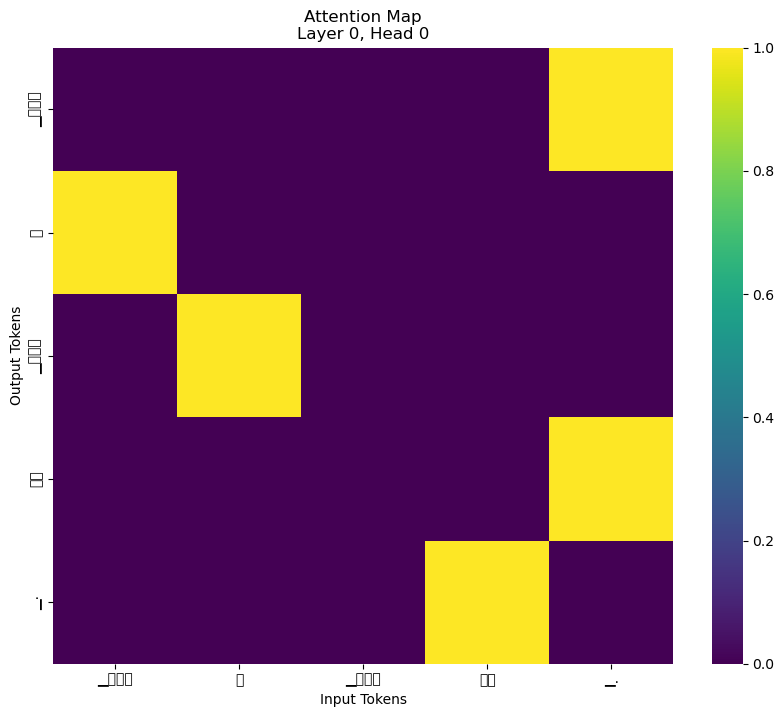

In [39]:
# Encoder Attention
plot_attention(
    enc_attns,
    src_tokens,
    src_tokens,
    layer=0,
    head=0
)

/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/c

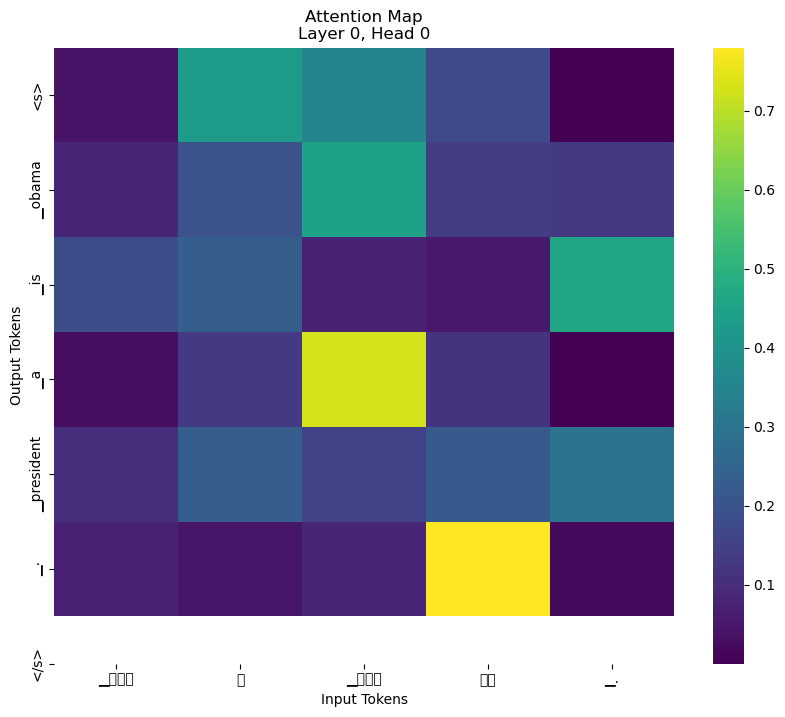

In [40]:
# Decoder Encoder Attention
plot_attention(
    dec_enc_attns,
    src_tokens,
    tgt_tokens,
    layer=0,
    head=0
)

In [41]:
translate(
    "오바마는 대통령이다.",
    model,
    ko_tokenizer,
    en_tokenizer
)

입력 문장 : 오바마는 대통령이다.
번역 결과 : obama is a president .


('obama is a president .',
 [tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
            [1.0000e+00, 0.0000e+00, 0.0000e+00, 5.4436e-15, 0.0000e+00],
            [0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00]],
  
           [[0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 4.6853e-36],
            [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00]],
  
           [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
            [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
   

In [42]:
# =====================================================
# Training Test (2 Epoch)
# =====================================================

import random
from tqdm.notebook import tqdm


# 테스트용 설정
BATCH_SIZE = 64
EPOCHS = 2   # ⭐ 먼저 2로 테스트


examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]


print("🚀 Transformer 학습 테스트 시작")


for epoch in range(EPOCHS):

    total_loss = 0


    # batch index 생성
    idx_list = list(
        range(
            0,
            enc_train.shape[0],
            BATCH_SIZE
        )
    )


    # 데이터 섞기
    random.shuffle(idx_list)


    progress = tqdm(
        idx_list,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )


    model.train()


    for batch, idx in enumerate(progress):

        src_batch = enc_train[
            idx:idx+BATCH_SIZE
        ]

        tgt_batch = dec_train[
            idx:idx+BATCH_SIZE
        ]


        loss, \
        enc_attns, \
        dec_attns, \
        dec_enc_attns = train_step(
            src_batch,
            tgt_batch,
            model,
            optimizer,
            scheduler
        )


        total_loss += loss


        progress.set_postfix(
            {
                "Loss":
                f"{total_loss/(batch+1):.4f}"
            }
        )


    avg_loss = total_loss / (batch+1)


    print("\n==============================")
    print(f"Epoch {epoch+1} 완료")
    print(f"Average Loss : {avg_loss:.4f}")
    print("==============================")


    # 학습 중간 번역 확인
    print("\n--- Translation Test ---")


    for sentence in examples:

        print("\n입력 :", sentence)

        translate(
            sentence,
            model,
            ko_tokenizer,
            en_tokenizer
        )


    print("\n" + "-"*50)

🚀 Transformer 학습 테스트 시작


Epoch 1/2:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 1 완료
Average Loss : 3.9529

--- Translation Test ---

입력 : 오바마는 대통령이다.
입력 문장 : 오바마는 대통령이다.
번역 결과 : obama is the president .

입력 : 시민들은 도시 속에 산다.
입력 문장 : 시민들은 도시 속에 산다.
번역 결과 : the city s main city is the city of the city .

입력 : 커피는 필요 없다.
입력 문장 : 커피는 필요 없다.
번역 결과 : no one is that you need to be a coffee .

입력 : 일곱 명의 사망자가 발생했다.
입력 문장 : 일곱 명의 사망자가 발생했다.
번역 결과 : the deaths were killed in the town of the dead .

--------------------------------------------------


Epoch 2/2:   0%|          | 0/1127 [00:00<?, ?it/s]


Epoch 2 완료
Average Loss : 3.7098

--- Translation Test ---

입력 : 오바마는 대통령이다.
입력 문장 : 오바마는 대통령이다.
번역 결과 : obama is the first lady .

입력 : 시민들은 도시 속에 산다.
입력 문장 : 시민들은 도시 속에 산다.
번역 결과 : the city is the city .

입력 : 커피는 필요 없다.
입력 문장 : 커피는 필요 없다.
번역 결과 : there are no coffee .

입력 : 일곱 명의 사망자가 발생했다.
입력 문장 : 일곱 명의 사망자가 발생했다.
번역 결과 : the death toll from the dead and .

--------------------------------------------------


### Transformer 한-영 번역기 프로젝트 회고

이번 프로젝트에서는 Transformer 구조를 직접 구현하여 한국어 문장을 영어로 번역하는 한-영 번역 모델을 제작하였다. 데이터 전처리부터 SentencePiece 토크나이저 구축, Transformer 모델 구현, 학습 및 Attention Map 시각화까지 번역 모델이 동작하는 전체 과정을 경험할 수 있었다.

처음에는 Transformer의 Encoder, Decoder, Multi-Head Attention, Positional Encoding 등 여러 구성 요소가 각각 어떤 역할을 하는지 이해하는 데 어려움이 있었다. 특히 Attention은 입력 문장의 어떤 단어에 집중하여 다음 단어를 생성하는 구조라는 점을 이해하는 것이 중요했고, 이를 통해 Transformer가 기존 RNN 기반 모델과 다르게 병렬 처리와 장기 의존성 학습에 강점을 가지는 이유를 알 수 있었다.

데이터 처리 과정에서는 korean-english-park 병렬 데이터를 사용하였고, 중복 문장을 제거하고 문장 길이를 제한한 뒤 SentencePiece를 활용하여 토큰화를 진행하였다. 단어 단위가 아닌 Subword 단위로 문장을 분리하는 방식을 적용하면서 자연어 처리에서 토크나이징 방법이 모델 성능에 큰 영향을 준다는 것을 알게 되었다.

모델 구현 과정에서는 Transformer 구조를 직접 작성하면서 각 모듈 간 데이터 흐름을 이해할 수 있었다. 특히 Encoder의 입력과 Decoder의 입력이 어떻게 연결되는지, Target Shift를 통해 이전 단어를 입력으로 받아 다음 단어를 예측하는 학습 방식을 이해할 수 있었다.

학습 과정에서는 처음 실행 시 `translate()` 함수가 정의되지 않았다는 오류가 발생하였다. 원인을 확인한 결과 모델 코드의 문제가 아니라 Jupyter Notebook에서 셀 실행 순서가 맞지 않아 발생한 문제였다. Training Loop에서는 학습 중 번역 결과를 확인하기 위해 `translate()` 함수를 호출하는데, 해당 함수가 포함된 Evaluate와 Translate 셀을 먼저 실행하지 않았기 때문에 발생한 오류였다.

이를 해결하기 위해 Evaluate 함수와 Translate 함수를 먼저 실행한 후 Training Loop를 다시 실행하였다. 이 경험을 통해 Jupyter 환경에서는 코드 작성 순서뿐만 아니라 실행 순서와 변수 및 함수 선언 상태를 관리하는 것이 중요하다는 것을 배웠다.

또한 초기 학습 단계에서는 바로 Epoch 20으로 학습하기보다 Epoch 2로 테스트하여 모델이 정상적으로 동작하는지 먼저 확인하는 방식으로 접근하였다. 이를 통해 긴 학습 시간을 낭비하지 않고 오류 발생 위치를 빠르게 확인하는 방법을 익혔다.

이번 프로젝트를 통해 단순히 Transformer 모델을 사용하는 것이 아니라, 데이터 준비부터 모델 구조 설계, 학습 과정, 추론, 결과 시각화까지 머신러닝 프로젝트의 전체 흐름을 경험할 수 있었다. 앞으로는 Attention Map 결과를 분석하여 모델이 어떤 입력 토큰에 집중하는지 확인하고, Hyperparameter 조정 및 성능 개선까지 진행해보고 싶다.

## 개선할 점

* Transformer 각 모듈의 수학적 원리에 대한 이해를 더욱 깊게 할 필요가 있다.
* 학습 결과를 개선하기 위해 Epoch 수, Batch Size, Vocabulary Size 등의 Hyperparameter 실험이 필요하다.
* Attention Map 분석을 통해 번역 결과와 모델의 판단 과정을 연결해서 해석하는 연습이 필요하다.
* Jupyter Notebook 환경에서는 셀 실행 순서와 변수 관리가 중요하므로 프로젝트 진행 시 코드 구조를 더욱 체계적으로 관리해야 한다.

## 프로젝트를 통해 얻은 점

이번 경험을 통해 자연어 처리 모델은 단순히 모델 구조만 구현한다고 완성되는 것이 아니라, 데이터 전처리, 토큰화, 학습 전략, 추론 과정까지 전체적인 파이프라인이 유기적으로 연결되어야 한다는 것을 배웠다. 또한 오류 발생 시 원인을 단계적으로 확인하고 해결하는 디버깅 과정의 중요성을 체감할 수 있었다.
